In [ ]:
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import shap

In [75]:
data = fashion_mnist.load_data()
(train_images,train_labels),(test_images,test_labels) = data


In [76]:
train_images.shape , train_labels.shape , test_images.shape , test_labels.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [77]:
train_images.dtype , train_labels.dtype , test_images.dtype , test_labels.dtype

(dtype('uint8'), dtype('uint8'), dtype('uint8'), dtype('uint8'))

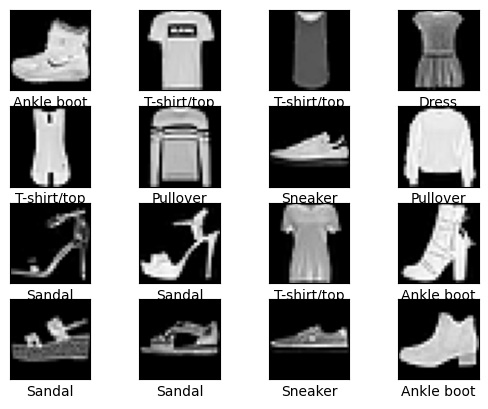

In [ ]:
class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(train_images[i],cmap='gray')
    plt.xlabel(clases_names[train_labels[i]])ٍْ

In [79]:
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0


In [ ]:
model = Sequential()
model.add(Flatten(input_shape=(28,28)))
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(10,activation='softmax'))

In [127]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [128]:
model.fit(train_images,train_labels,epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.8204 - loss: 0.5048
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8651 - loss: 0.3713
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8756 - loss: 0.3358
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8842 - loss: 0.3127
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8918 - loss: 0.2933
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8964 - loss: 0.2765
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8994 - loss: 0.2682
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9042 - loss: 0.2559
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9075 - loss: 0.2458
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9102 - loss: 0.2376


In [83]:
test_loss, test_acc = model.evaluate(test_images, test_labels)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8782 - loss: 0.3378


In [84]:
predictions_array = model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [85]:
def plot_image(i, predictions_array, images, labels):
    predictions = predictions_array[i]
    image = images[i]
    true_label = labels[i]

    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(image, cmap='gray')

    predicted_label = np.argmax(predictions)

    if predicted_label == true_label:
        color = "blue"
    else:
        color = "red"

    plt.xlabel(
        "{} ({})".format(
            class_names[predicted_label],
            class_names[true_label]
        ),
        color=color
    )

In [87]:
def plot_value_array(i, predictions_array, true_label):
    predictions_array, true_label = predictions_array, true_label[i]
    plt.xticks(range(10))
    plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)

    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')
    i = 1

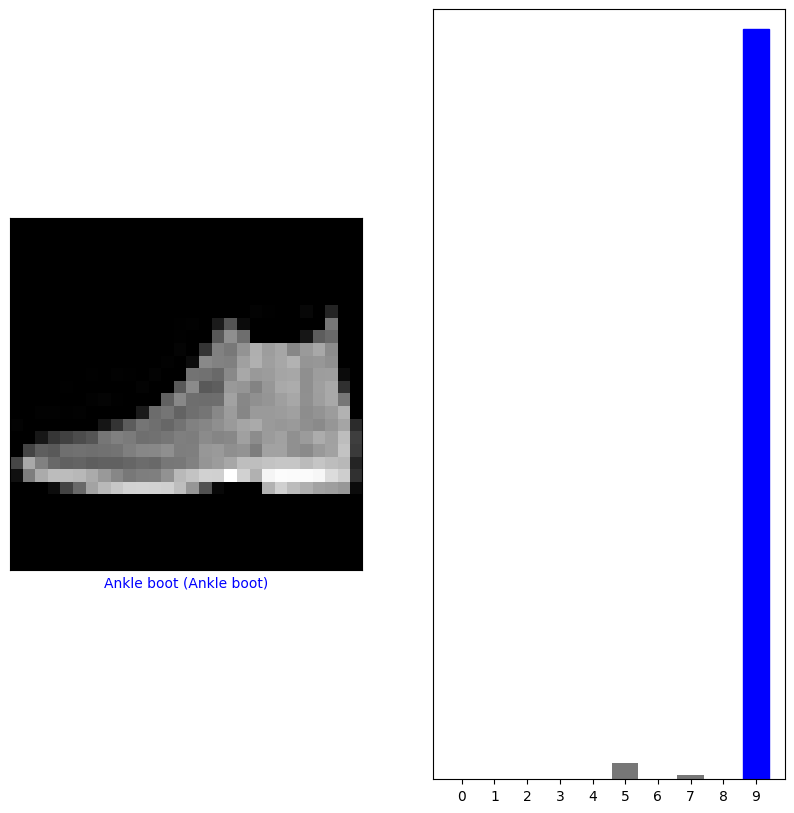

In [ ]:
i = 0

plt.figure(figsize=(10,10))

plt.subplot(1,2,1)
plot_image(i, predictions_array, test_images, test_labels)

plt.subplot(1,2,2)
plot_value_array(i, predictions_array[i], test_labels)

plt.show()

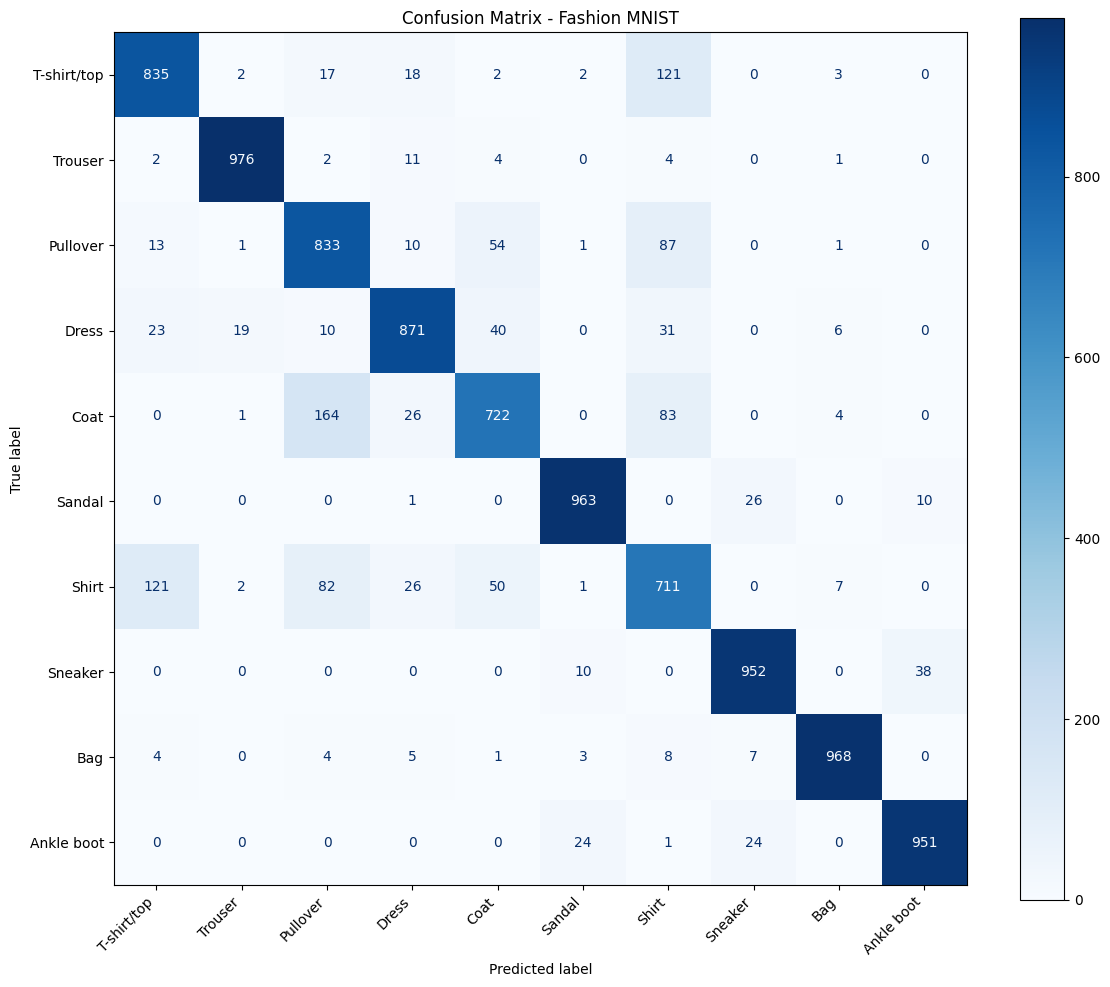

In [98]:
y_pred = np.argmax(predictions_array,axis=1)
cm = confusion_matrix(test_labels,y_pred)
plt.figure(figsize=(12,10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=class_names)
disp.plot(cmap='Blues',ax=plt.gca())
plt.title('Confusion Matrix - Fashion MNIST')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\king\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_26
Received: inputs=['Tensor(shape=(5, 28, 28))']
  warnings.warn(msg)


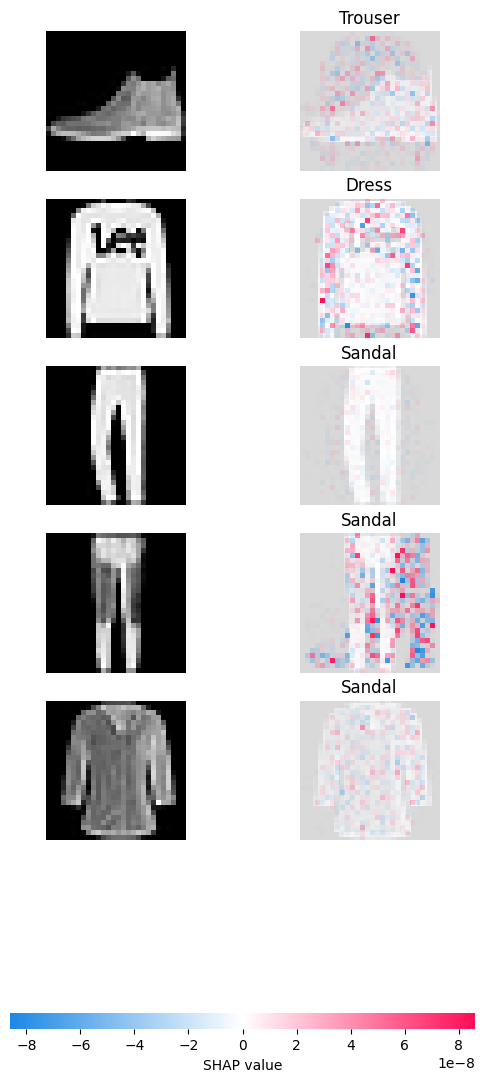

In [ ]:

background = train_images[:100]

test_sample = test_images[:5]


predictions = model.predict(test_sample, verbose=0)

predicted_labels = np.argmax(predictions, axis=1)

predicted_names = [class_names[i] for i in predicted_labels]

explainer = shap.DeepExplainer(model, background)

shap_values = explainer.shap_values(test_sample)

shap.image_plot(
    shap_values,
    test_sample,
    labels=predicted_names
)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

y_pred = np.argmax(predictions_array, axis=1)

correct_indices = np.where(y_pred == test_labels)[0]
wrong_indices   = np.where(y_pred != test_labels)[0]

print(f"Number of Correct Predictions : {len(correct_indices)}")
print(f"Number of Wrong Predictions   : {len(wrong_indices)}")

Number of Correct Predictions : 8782
Number of Wrong Predictions   : 1218


In [105]:
def show_predictions(indices, title, num_images=5):

    plt.figure(figsize=(15,4))
    plt.suptitle(title, fontsize=15)

    for i in range(num_images):

        idx = indices[i]

        plt.subplot(1, num_images, i+1)

        plt.imshow(test_images[idx], cmap='gray')

        plt.title(
            f"Pred: {class_names[y_pred[idx]]}\n"
            f"True: {class_names[test_labels[idx]]}",
            fontsize=9
        )

        plt.axis('off')

    plt.tight_layout()
    plt.show()

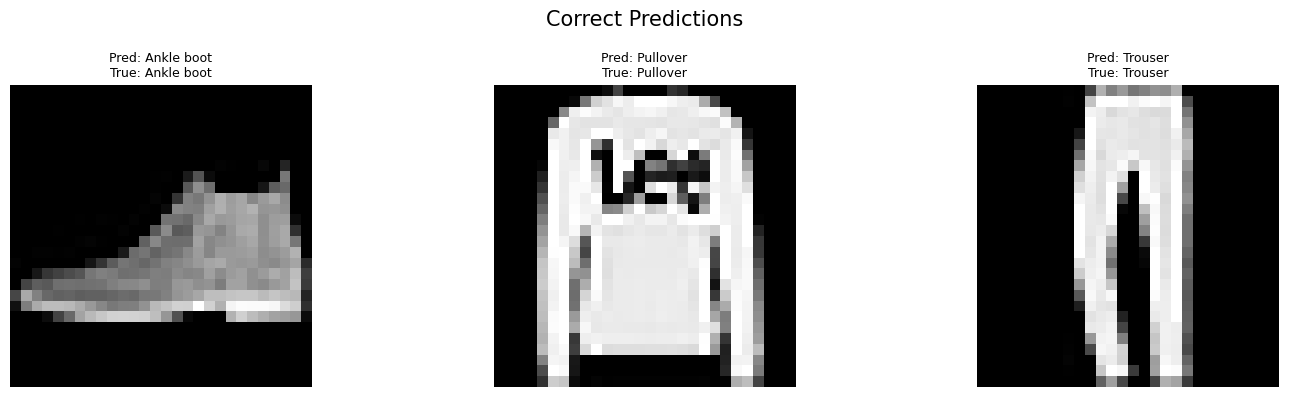

In [107]:
show_predictions(
    correct_indices,
    "Correct Predictions",
    num_images=3
)

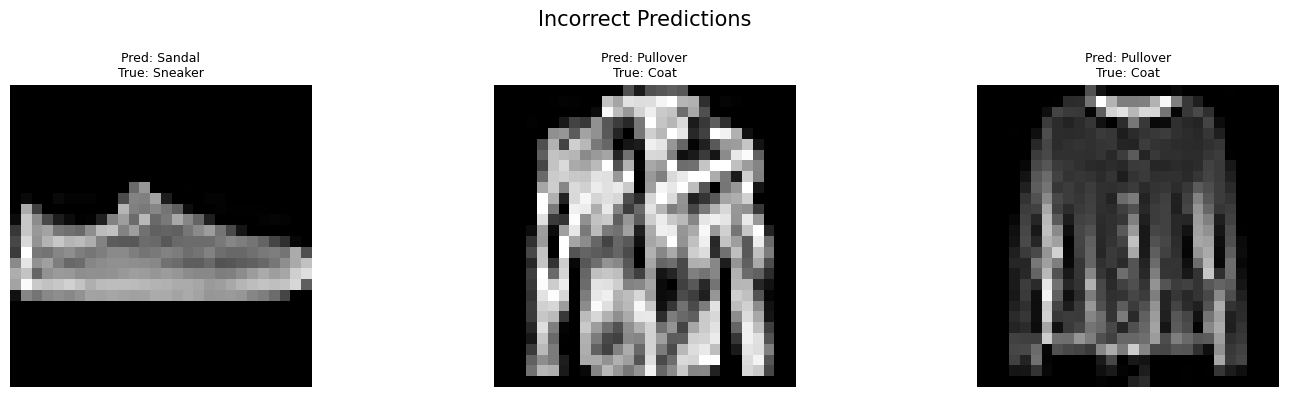

In [109]:
show_predictions(
    wrong_indices,
    "Incorrect Predictions",
    num_images=3
)

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt


def explain_prediction(index):

    image = test_images[index:index+1]

    prediction = model.predict(image, verbose=0)

    predicted_label = np.argmax(prediction)

    true_label = test_labels[index]

    shap_values = explainer.shap_values(image)

    shap.image_plot(
        shap_values,
        image,
        labels=[class_names[predicted_label]]
    )

    print("="*50)
    print(f"Image Index      : {index}")
    print(f"True Label       : {class_names[true_label]}")
    print(f"Predicted Label  : {class_names[predicted_label]}")
    print(f"Confidence       : {prediction[0][predicted_label]*100:.2f}%")

    if predicted_label == true_label:
        print("Prediction : Correct")
    else:
        print("Prediction : Incorrect")

C:\Users\king\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_26
Received: inputs=['Tensor(shape=(1, 28, 28))']
  warnings.warn(msg)


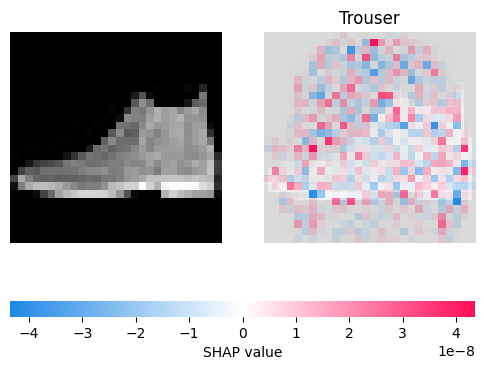

Image Index      : 0
True Label       : Ankle boot
Predicted Label  : Trouser
Confidence       : 14.71%
Prediction : Incorrect


In [111]:
explain_prediction(correct_indices[0])

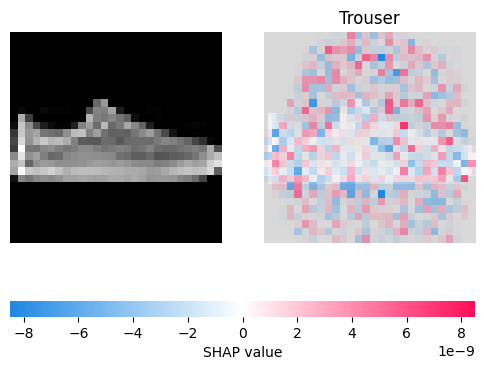

Image Index      : 12
True Label       : Sneaker
Predicted Label  : Trouser
Confidence       : 14.90%
Prediction : Incorrect


In [112]:
explain_prediction(wrong_indices[0])

# Feature Importance Analysis

## Important Features Learned by the Model

| Class | Important Features |
|---|---|
| T-shirt/Top | Sleeves and upper body outline |
| Trouser | Two long vertical leg regions |
| Pullover | Thick sleeves and torso |
| Dress | Long vertical body shape |
| Coat | Long outer edges and sleeves |
| Sandal | Open foot structure |
| Shirt | Shoulder and collar region |
| Sneaker | Sole edges and toe region |
| Bag | Rectangular body and handle |
| Ankle Boot | Sole and upper shaft |

The SHAP explanations indicate that the model focuses primarily on the overall silhouette and discriminative edges.

# Error Analysis

## Interpretation of Misclassified Samples

The model performs well overall, but errors occur because Fashion-MNIST images are only 28×28 grayscale.

- **Shirt → T-shirt/Top:** Similar outlines and missing collar details.
- **Sneaker → Ankle Boot:** Similar sole and edge patterns.
- **Pullover → Coat:** Similar silhouettes with limited texture information.

These mistakes indicate the model relies mainly on shape rather than fine details.

# Results & Interpretation

## Model Performance

- The model achieved high classification accuracy on the Fashion-MNIST test set.
- The confusion matrix shows that visually similar classes are confused more frequently.

### Most Confused Classes
- Shirt ↔ T-shirt/Top
- Coat ↔ Pullover
- Sneaker ↔ Ankle Boot

### What the Model Learned
- Object outline
- Sleeve locations
- Shoe soles
- Bag handles

### Where the Model Fails
- Similar silhouettes
- Low-resolution images
- Missing fine-grained texture

### Why SHAP Highlights These Regions
SHAP emphasizes pixels that contribute most to the prediction. It typically highlights the object boundaries and distinctive structural regions instead of the background.

### Conclusion
The MLP classifier performs well on Fashion-MNIST. SHAP explanations confirm that the network learns meaningful visual patterns, while most errors occur between visually similar clothing categories.